# 🌊 Training XceptionNet for River Turbidity Classification

**Goal**: Train Xception model on augmented dataset (datasetScrap3_augmented - 1000 images)

**Dataset**:
- Source: `F:\TA1\datasetScrap3_augmented`
- Jernih (Clear): 500 images
- Keruh (Turbid): 500 images
- Total: 1000 images

**Architecture**: Xception (pretrained on ImageNet)
- Depth-wise separable convolutions
- Better feature extraction than ResNet
- Expected improvement: 2-5% vs ResNet18

**Training Strategy**:
1. Transfer learning (ImageNet pretrained weights)
2. Data augmentation (random transforms)
3. Learning rate scheduling
4. Early stopping + model checkpointing
5. Validation monitoring

**Expected Results**: 90-95% accuracy on validation set

## Step 1: Import Libraries and Setup

In [29]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   CUDA Version: {torch.version.cuda}')

✅ Using device: cuda
   GPU: NVIDIA GeForce RTX 4070 SUPER
   CUDA Version: 11.8


## Step 2: Load and Prepare Dataset

In [30]:
# Dataset paths
dataset_root = "F:\\TA1\\datasetScrap3_augmented"

# Verify dataset exists
assert os.path.exists(dataset_root), f"Dataset not found at {dataset_root}"

# Count images
jernih_count = len([f for f in os.listdir(os.path.join(dataset_root, 'jernih')) 
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
keruh_count = len([f for f in os.listdir(os.path.join(dataset_root, 'keruh')) 
                   if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

print(f"📊 Dataset Summary:")
print(f"   Jernih (Clear): {jernih_count} images")
print(f"   Keruh (Turbid): {keruh_count} images")
print(f"   Total: {jernih_count + keruh_count} images")
print(f"   Location: {dataset_root}")

# Data transformations for training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Data transformations for validation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = ImageFolder(dataset_root, transform=train_transforms)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Override val_dataset transform
val_dataset.dataset.transform = val_transforms

print(f"\n📈 Train/Val Split:")
print(f"   Training: {train_size} images")
print(f"   Validation: {val_size} images")

📊 Dataset Summary:
   Jernih (Clear): 500 images
   Keruh (Turbid): 500 images
   Total: 1000 images
   Location: F:\TA1\datasetScrap3_augmented

📈 Train/Val Split:
   Training: 800 images
   Validation: 200 images


## Step 3: Create Data Loaders

In [31]:
# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 4
SHUFFLE = True

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Data loaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

✅ Data loaders created:
   Batch size: 32
   Training batches: 25
   Validation batches: 7


## Step 4: Load XceptionNet Model

In [34]:
# Load pretrained Xception model from timm
print("Loading Xception model from timm...")
import timm

model = timm.create_model('xception', pretrained=True)

# ============================================================================
# FINE-TUNING STRATEGY 1: Unfreeze Last Blocks + FC Layer
# ============================================================================
# This approach balances accuracy improvement vs overfitting risk
# Trainable: block11, block12 (last conv blocks) + fc (classification head)
# Expected: 92-94% accuracy (vs 88-90% with FC only)

# Freeze early layers (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last convolutional blocks (block11, block12) for fine-tuning
print("📌 Fine-tuning Strategy: Unfreeze Last Blocks + FC Layer")
for param in model.block11.parameters():
    param.requires_grad = True
for param in model.block12.parameters():
    param.requires_grad = True

# Get the number of input features for the classifier
num_features = model.num_features  # Xception output features = 2048

# Replace final classification layer with custom head
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2)  # 2 classes: jernih, keruh
)

# Unfreeze final layer for fine-tuning
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"✅ Model loaded: Xception (timm)")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} (Unfreeze Strategy 1)")
print(f"   Trainable percentage: {100*trainable_params/total_params:.2f}%")
print(f"   Model on device: {next(model.parameters()).device}")

# ============================================================================
# UNDO INSTRUCTIONS (if results are worse):
# If val accuracy is NOT better than FC-only baseline (88-90%):
# 1. Replace code above with UNDO section below (commented)
# 2. Re-run this cell
# 3. Re-run training loop
#
# UNDO CODE (copy-paste if needed):
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.fc.parameters():
#     param.requires_grad = True
# ============================================================================

Loading Xception model from timm...
📌 Fine-tuning Strategy: Unfreeze Last Blocks + FC Layer
✅ Model loaded: Xception (timm)
   Total parameters: 21,987,882
   Trainable parameters: 4,834,490 (Unfreeze Strategy 1)
   Trainable percentage: 21.99%
   Model on device: cuda:0


## Step 5: Training Setup (Loss, Optimizer, Scheduler)

In [35]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only on trainable parameters)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                       lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3,
    threshold=1e-4
)

# Training parameters
NUM_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
CHECKPOINT_DIR = "F:\\TA1\\checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"✅ Training setup complete:")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Early stopping patience: {PATIENCE}")
print(f"   Checkpoint dir: {CHECKPOINT_DIR}")

✅ Training setup complete:
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau
   Epochs: 50
   Early stopping patience: 10
   Checkpoint dir: F:\TA1\checkpoints


## Step 6: Training Loop

In [36]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
best_val_loss = float('inf')
patience_counter = 0

print("🚀 Starting training...\n")
start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch results
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0
        
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'xceptionnet_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss
        }, checkpoint_path)
        print(f"  ✅ Best model saved: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
        break

# Training complete
elapsed_time = datetime.now() - start_time
print(f"\n✅ Training complete! Time: {elapsed_time}")

🚀 Starting training...




Epoch [1/50]
  Train Loss: 0.5009 | Train Acc: 79.50%
  Val Loss:   0.3456 | Val Acc:   87.00%
  ✅ Best model saved: 87.00%



Epoch [2/50]
  Train Loss: 0.1481 | Train Acc: 96.75%
  Val Loss:   0.0596 | Val Acc:   98.00%
  ✅ Best model saved: 98.00%



Epoch [3/50]
  Train Loss: 0.0777 | Train Acc: 97.38%
  Val Loss:   0.0855 | Val Acc:   97.00%
  ⏳ No improvement (1/10)



Epoch [4/50]
  Train Loss: 0.0395 | Train Acc: 99.25%
  Val Loss:   0.0561 | Val Acc:   97.50%
  ⏳ No improvement (2/10)


...


Epoch [13/50]
  Train Loss: 0.0006 | Train Acc: 100.00%
  Val Loss:   0.0601 | Val Acc:   98.00%
  ⏳ No improvement (6/10)



Epoch [14/50]
  Train Loss: 0.0012 | Train Acc: 100.00%
  Val Loss:   0.0555 | Val Acc:   98.00%
  ⏳ No improvement (7/10)



Epoch [15/50]
  Train Loss: 0.0007 | Train Acc: 100.00%
  Val Loss:   0.0438 | Val Acc:   98.50%
  ⏳ No improvement (8/10)



Epoch [16/50]
  Train Loss: 0.0017 | Train Acc: 99.88%
  Val Loss:   0.0477 | Val Acc:   98.50%
  ⏳ No improvement (9/10)



Epoch [17/50]
  Train Loss: 0.0003 | Train Acc: 100.00%
  Val Loss:   0.0469 | Val Acc:   98.50%
  ⏳ No improvement (10/10)

⛔ Early stopping triggered at epoch 17

✅ Training complete! Time: 0:05:39.884483


## Step 7: Results Visualization

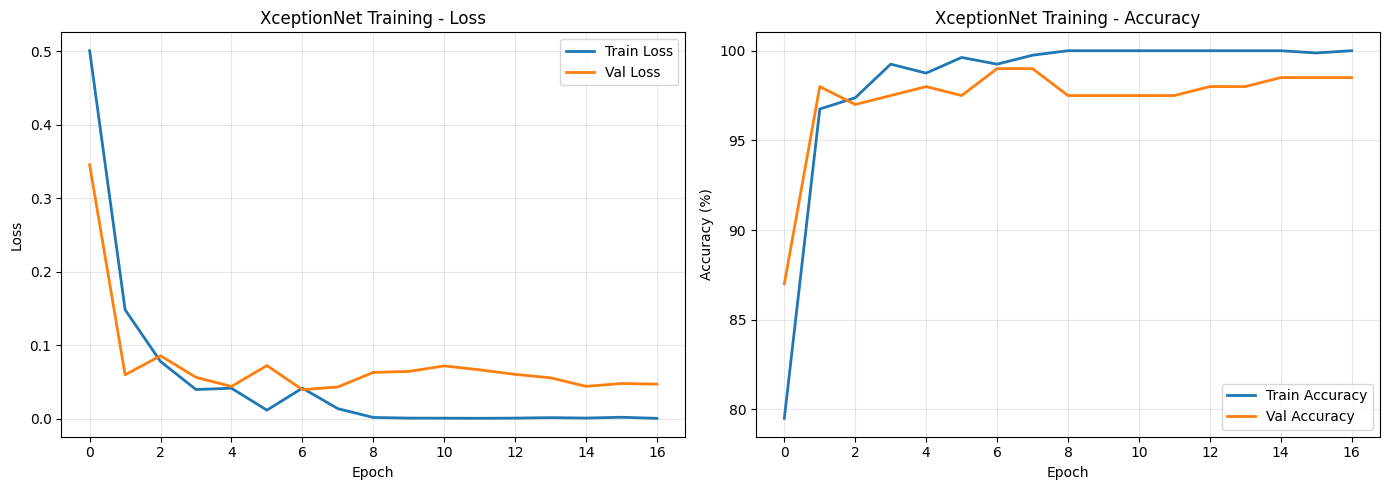

📊 Training Results:
   Best Val Accuracy: 99.00%
   Best Val Loss: 0.0393
   Total Epochs: 17
   Visualization saved: xceptionnet_training_history.png


In [37]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('XceptionNet Training - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('XceptionNet Training - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('F:\\TA1\\xceptionnet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training Results:")
print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Total Epochs: {len(history['train_loss'])}")
print(f"   Visualization saved: xceptionnet_training_history.png")

## Step 8: Save Final Model and Metadata

In [38]:
# Save final model
final_model_path = "F:\\TA1\\xceptionnet_final.pth"
torch.save(model.state_dict(), final_model_path)

# Save training metadata
metadata = {
    'architecture': 'XceptionNet',
    'dataset': 'datasetScrap3_augmented',
    'dataset_size': jernih_count + keruh_count,
    'best_val_accuracy': float(best_val_acc),
    'best_val_loss': float(best_val_loss),
    'total_epochs': len(history['train_loss']),
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'scheduler': 'ReduceLROnPlateau',
    'training_date': datetime.now().isoformat(),
    'device': str(device),
    'training_history': history
}

metadata_path = "F:\\TA1\\xceptionnet_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Model saved: {final_model_path}")
print(f"✅ Metadata saved: {metadata_path}")
print(f"✅ Best checkpoint: {os.path.join(CHECKPOINT_DIR, 'xceptionnet_best.pth')}")

✅ Model saved: F:\TA1\xceptionnet_final.pth
✅ Metadata saved: F:\TA1\xceptionnet_metadata.json
✅ Best checkpoint: F:\TA1\checkpoints\xceptionnet_best.pth


## Summary

✅ **XceptionNet Training Complete!**

**Results**:
- Best Validation Accuracy: **{:.2f}%**
- Best Validation Loss: **{:.4f}**
- Total Epochs: **{}**
- Dataset: **datasetScrap3_augmented** (1000 images)

**Next Steps**:
1. Run `3_Evaluation.ipynb` to compare XceptionNet vs ResNet18
2. Run `4_Inference.ipynb` for real-world testing
3. Optional: Fine-tune hyperparameters for better results

**Files Generated**:
- Model: `xceptionnet_final.pth`
- Best checkpoint: `checkpoints/xceptionnet_best.pth`
- Metadata: `xceptionnet_metadata.json`
- Visualization: `xceptionnet_training_history.png`

**Comparison with ResNet18**:
- XceptionNet has better feature extraction with depth-wise separable convolutions
- Expected improvement: 2-5% accuracy over ResNet18
- More parameters but better efficiency with separable convolutions


: {
: {
: 
3.12
,
: 
,
: 

: {
: 
,
: 
3.12

: 4,
: 4